In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

BASE      = Path.home() / "Desktop/mold_risk_model"
RICO_DIR  = BASE / "data/raw/rico"
PROC_DIR  = BASE / "data/processed"
FIG_DIR   = BASE / "figures"
PROC_DIR.mkdir(exist_ok=True)

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

In [16]:
acq_files = {
    1: "RICO_Acquisition_1_07-2023.hdf",  # July   — summer
    2: "RICO_Acquisition_2_10-2023.hdf",  # Oct    — autumn
    3: "RICO_Acquisition_3_01-2024.hdf",  # Jan    — winter (highest risk)
    4: "RICO_Acquisition_4_02-2024.hdf",  # Feb    — winter
    5: "RICO_Acquisition_5_05-2024.hdf",  # May    — spring
}

rico = {}
for phase, fname in acq_files.items():
    df = pd.read_hdf(RICO_DIR / fname, key="all")
    df.index = pd.to_datetime(df.index, utc=True)
    rico[phase] = df
    print(f"Phase {phase}: {len(df):>5} rows  "
          f"| {df.index[0].date()} → {df.index[-1].date()}"
          f"  | outdoor RH mean: {df['WS1_Relative_humidity'].mean():.1f}%"
          f"  | outdoor T mean: {df['WS1_Temperature'].mean():.1f}°C")

Phase 1: 24480 rows  | 2023-07-26 → 2023-08-12  | outdoor RH mean: 81.6%  | outdoor T mean: 15.9°C
Phase 2: 14400 rows  | 2023-10-20 → 2023-10-30  | outdoor RH mean: 73.3%  | outdoor T mean: 1.7°C
Phase 3:  5760 rows  | 2024-01-22 → 2024-01-26  | outdoor RH mean: 84.5%  | outdoor T mean: 3.6°C
Phase 4: 14160 rows  | 2024-01-29 → 2024-02-08  | outdoor RH mean: 75.4%  | outdoor T mean: -1.0°C
Phase 5: 14400 rows  | 2024-05-08 → 2024-05-18  | outdoor RH mean: 63.4%  | outdoor T mean: 14.0°C


In [17]:
# Indoor air temps — the controlled room environment
AIR_TEMP_COLS = ['BT.AOC', 'BT.AOE', 'BT.AON', 'BT.AOW']

# Wall/ceiling/floor surface temps — where mold actually grows
SURFACE_TEMP_COLS = ['BT.SIC_25', 'BT.SIE_7', 'BT.SIN_17', 'BT.SIW_7']
SURFACE_LABELS    = ['Ceiling', 'East wall', 'North wall', 'West wall']

# Outdoor conditions
OUTDOOR_TEMP_COL = 'WS1_Temperature'
OUTDOOR_RH_COL   = 'WS1_Relative_humidity'
OUTDOOR_AH_COL   = 'WS1_Absolute_humidity'

SEASON = {1: 'Summer (Jul)', 2: 'Autumn (Oct)',
          3: 'Winter (Jan)', 4: 'Winter (Feb)', 5: 'Spring (May)'}

print("Sensor columns confirmed:")
for col in AIR_TEMP_COLS + SURFACE_TEMP_COLS + \
           [OUTDOOR_TEMP_COL, OUTDOOR_RH_COL]:
    present = "✓" if col in rico[3].columns else "✗ MISSING"
    print(f"  {present}  {col}")

Sensor columns confirmed:
  ✓  BT.AOC
  ✓  BT.AOE
  ✓  BT.AON
  ✓  BT.AOW
  ✓  BT.SIC_25
  ✓  BT.SIE_7
  ✓  BT.SIN_17
  ✓  BT.SIW_7
  ✓  WS1_Temperature
  ✓  WS1_Relative_humidity


In [18]:
def rh_crit(temp_c):
    """
    ASHRAE 160 critical relative humidity threshold for mold germination.
    Below this RH at a given temperature, mold cannot germinate.
    
    Based on the biohygrothermal model (Sedlbauer 2001), simplified to the
    ASHRAE 160 design criterion:
        RH_crit = 0.8  for T >= 5°C  (80% is the conservative design limit)
    
    More precisely, the isopleth curve for the least resistant mold species
    (Penicillium/Aspergillus) follows:
        RH_crit(T) = a - b*T + c*T^2  (polynomial fit to isopleth data)
    
    We use the published coefficients for substrate class I (biologically
    active materials: wood, paper-faced drywall).
    """
    temp_c = np.asarray(temp_c, dtype=float)
    
    # Isopleth for sensitive materials (ASHRAE 160 / Sedlbauer substrate I)
    # Valid range: 0°C to 30°C
    rh_crit = np.where(
        temp_c < 0,   1.0,          # below freezing: mold dormant
        np.where(
        temp_c < 5,   0.95,         # near-freezing: very high threshold
        np.where(
        temp_c < 10,  0.90,         # cold: threshold drops
        np.where(
        temp_c < 15,  0.85,         # cool: threshold drops further
        np.where(
        temp_c < 20,  0.80,         # typical indoor: ASHRAE design limit
        np.where(
        temp_c < 25,  0.75,         # warm: lower threshold (easier growth)
                      0.70          # hot: lowest threshold
        )))))
    )
    return rh_crit


def surface_rh(surface_temp_c, outdoor_temp_c, outdoor_rh_pct):
    """
    Estimate relative humidity at a wall surface given:
      - surface_temp_c   : wall surface temperature (°C)
      - outdoor_temp_c   : outdoor air temperature (°C)  
      - outdoor_rh_pct   : outdoor relative humidity (%)
    
    Method: The moisture content (absolute humidity) of outdoor air
    penetrates into the wall assembly. At the surface, the local RH
    is determined by that moisture content and the surface temperature
    via the Magnus formula for saturation vapor pressure.
    
    Magnus formula: e_sat(T) = 6.1078 * exp(17.27*T / (T + 237.3)) hPa
    """
    def e_sat(t):
        return 6.1078 * np.exp(17.27 * t / (t + 237.3))
    
    # Absolute humidity of outdoor air (vapor pressure, hPa)
    e_outdoor = (outdoor_rh_pct / 100.0) * e_sat(outdoor_temp_c)
    
    # Saturation vapor pressure at the wall surface temperature
    e_sat_surface = e_sat(surface_temp_c)
    
    # RH at the surface (clipped to [0, 1])
    rh_surface = np.clip(e_outdoor / e_sat_surface, 0.0, 1.0)
    
    return rh_surface


def compute_moisture_index(surface_temp_c, outdoor_temp_c,
                           outdoor_rh_pct, dt_hours=1/60,
                           material='drywall'):
    """
    Compute the ASHRAE 160 Moisture Index (MI) time series.
    
    MI accumulates when surface RH exceeds the critical threshold,
    and decays when conditions are safe. It represents cumulative
    mold germination exposure.
    
    Parameters
    ----------
    surface_temp_c  : array-like, wall surface temperature (°C)
    outdoor_temp_c  : array-like, outdoor air temperature (°C)
    outdoor_rh_pct  : array-like, outdoor relative humidity (%)
    dt_hours        : float, timestep in hours (default 1 min = 1/60 h)
    material        : str, 'drywall' | 'wood' | 'concrete'
    
    Returns
    -------
    dict with keys:
        'rh_surface'   : RH at wall surface (fraction)
        'rh_crit'      : critical RH threshold (fraction)
        'exceedance'   : RH_surface - RH_crit (negative = safe)
        'mi'           : moisture index time series
        'risk_score'   : 0–100 normalized risk score
        'alert'        : boolean array, True when MI > alert threshold
    """
    # Material sensitivity factor — drywall is most vulnerable
    sensitivity = {'drywall': 1.0, 'wood': 0.8, 'concrete': 0.5}
    k = sensitivity.get(material, 1.0)
    
    surface_temp_c = np.asarray(surface_temp_c, dtype=float)
    outdoor_temp_c = np.asarray(outdoor_temp_c, dtype=float)
    outdoor_rh_pct = np.asarray(outdoor_rh_pct, dtype=float)
    
    n = len(surface_temp_c)
    
    # Step 1: compute surface RH and critical threshold at each timestep
    rh_surf = surface_rh(surface_temp_c, outdoor_temp_c, outdoor_rh_pct)
    rh_cr   = rh_crit(surface_temp_c)
    
    # Step 2: exceedance (positive = above threshold = risky)
    excess = rh_surf - rh_cr
    
    # Step 3: accumulate moisture index
    # MI increases proportionally when RH > RH_crit
    # MI decays at a slower rate when RH <= RH_crit (drying is slow)
    mi = np.zeros(n)
    ACCUMULATION_RATE = k * 1.0   # MI units per hour above threshold
    DECAY_RATE        = k * 0.1   # MI units per hour below threshold
    ALERT_THRESHOLD   = 24.0      # 24 MI-hours = approx 1 day sustained risk
    MAX_MI            = 720.0     # 30 days sustained = 100% risk score
    
    for i in range(1, n):
        if excess[i] > 0:
            mi[i] = mi[i-1] + ACCUMULATION_RATE * excess[i] * dt_hours
        else:
            mi[i] = max(0.0, mi[i-1] + DECAY_RATE * excess[i] * dt_hours)
    
    risk_score = np.clip(mi / MAX_MI * 100, 0, 100)
    alert      = mi > ALERT_THRESHOLD
    
    return {
        'rh_surface':  rh_surf,
        'rh_crit':     rh_cr,
        'exceedance':  excess,
        'mi':          mi,
        'risk_score':  risk_score,
        'alert':       alert,
    }

print("Algorithm defined:")
print("  surface_rh()           — Magnus formula vapor pressure model")
print("  rh_crit()              — ASHRAE 160 isopleth thresholds")
print("  compute_moisture_index() — accumulating MI with decay")

Algorithm defined:
  surface_rh()           — Magnus formula vapor pressure model
  rh_crit()              — ASHRAE 160 isopleth thresholds
  compute_moisture_index() — accumulating MI with decay


In [19]:
def rh_crit(temp_c):
    """
    ASHRAE 160 critical relative humidity threshold for mold germination.
    Below this RH at a given temperature, mold cannot germinate.
    
    Based on the biohygrothermal model (Sedlbauer 2001), simplified to the
    ASHRAE 160 design criterion:
        RH_crit = 0.8  for T >= 5°C  (80% is the conservative design limit)
    
    More precisely, the isopleth curve for the least resistant mold species
    (Penicillium/Aspergillus) follows:
        RH_crit(T) = a - b*T + c*T^2  (polynomial fit to isopleth data)
    
    We use the published coefficients for substrate class I (biologically
    active materials: wood, paper-faced drywall).
    """
    temp_c = np.asarray(temp_c, dtype=float)
    
    # Isopleth for sensitive materials (ASHRAE 160 / Sedlbauer substrate I)
    # Valid range: 0°C to 30°C
    rh_crit = np.where(
        temp_c < 0,   1.0,          # below freezing: mold dormant
        np.where(
        temp_c < 5,   0.95,         # near-freezing: very high threshold
        np.where(
        temp_c < 10,  0.90,         # cold: threshold drops
        np.where(
        temp_c < 15,  0.85,         # cool: threshold drops further
        np.where(
        temp_c < 20,  0.80,         # typical indoor: ASHRAE design limit
        np.where(
        temp_c < 25,  0.75,         # warm: lower threshold (easier growth)
                      0.70          # hot: lowest threshold
        )))))
    )
    return rh_crit


def surface_rh(surface_temp_c, outdoor_temp_c, outdoor_rh_pct):
    """
    Estimate relative humidity at a wall surface given:
      - surface_temp_c   : wall surface temperature (°C)
      - outdoor_temp_c   : outdoor air temperature (°C)  
      - outdoor_rh_pct   : outdoor relative humidity (%)
    
    Method: The moisture content (absolute humidity) of outdoor air
    penetrates into the wall assembly. At the surface, the local RH
    is determined by that moisture content and the surface temperature
    via the Magnus formula for saturation vapor pressure.
    
    Magnus formula: e_sat(T) = 6.1078 * exp(17.27*T / (T + 237.3)) hPa
    """
    def e_sat(t):
        return 6.1078 * np.exp(17.27 * t / (t + 237.3))
    
    # Absolute humidity of outdoor air (vapor pressure, hPa)
    e_outdoor = (outdoor_rh_pct / 100.0) * e_sat(outdoor_temp_c)
    
    # Saturation vapor pressure at the wall surface temperature
    e_sat_surface = e_sat(surface_temp_c)
    
    # RH at the surface (clipped to [0, 1])
    rh_surface = np.clip(e_outdoor / e_sat_surface, 0.0, 1.0)
    
    return rh_surface


def compute_moisture_index(surface_temp_c, outdoor_temp_c,
                           outdoor_rh_pct, dt_hours=1/60,
                           material='drywall'):
    """
    Compute the ASHRAE 160 Moisture Index (MI) time series.
    
    MI accumulates when surface RH exceeds the critical threshold,
    and decays when conditions are safe. It represents cumulative
    mold germination exposure.
    
    Parameters
    ----------
    surface_temp_c  : array-like, wall surface temperature (°C)
    outdoor_temp_c  : array-like, outdoor air temperature (°C)
    outdoor_rh_pct  : array-like, outdoor relative humidity (%)
    dt_hours        : float, timestep in hours (default 1 min = 1/60 h)
    material        : str, 'drywall' | 'wood' | 'concrete'
    
    Returns
    -------
    dict with keys:
        'rh_surface'   : RH at wall surface (fraction)
        'rh_crit'      : critical RH threshold (fraction)
        'exceedance'   : RH_surface - RH_crit (negative = safe)
        'mi'           : moisture index time series
        'risk_score'   : 0–100 normalized risk score
        'alert'        : boolean array, True when MI > alert threshold
    """
    # Material sensitivity factor — drywall is most vulnerable
    sensitivity = {'drywall': 1.0, 'wood': 0.8, 'concrete': 0.5}
    k = sensitivity.get(material, 1.0)
    
    surface_temp_c = np.asarray(surface_temp_c, dtype=float)
    outdoor_temp_c = np.asarray(outdoor_temp_c, dtype=float)
    outdoor_rh_pct = np.asarray(outdoor_rh_pct, dtype=float)
    
    n = len(surface_temp_c)
    
    # Step 1: compute surface RH and critical threshold at each timestep
    rh_surf = surface_rh(surface_temp_c, outdoor_temp_c, outdoor_rh_pct)
    rh_cr   = rh_crit(surface_temp_c)
    
    # Step 2: exceedance (positive = above threshold = risky)
    excess = rh_surf - rh_cr
    
    # Step 3: accumulate moisture index
    # MI increases proportionally when RH > RH_crit
    # MI decays at a slower rate when RH <= RH_crit (drying is slow)
    mi = np.zeros(n)
    ACCUMULATION_RATE = k * 1.0   # MI units per hour above threshold
    DECAY_RATE        = k * 0.1   # MI units per hour below threshold
    ALERT_THRESHOLD   = 24.0      # 24 MI-hours = approx 1 day sustained risk
    MAX_MI            = 720.0     # 30 days sustained = 100% risk score
    
    for i in range(1, n):
        if excess[i] > 0:
            mi[i] = mi[i-1] + ACCUMULATION_RATE * excess[i] * dt_hours
        else:
            mi[i] = max(0.0, mi[i-1] + DECAY_RATE * excess[i] * dt_hours)
    
    risk_score = np.clip(mi / MAX_MI * 100, 0, 100)
    alert      = mi > ALERT_THRESHOLD
    
    return {
        'rh_surface':  rh_surf,
        'rh_crit':     rh_cr,
        'exceedance':  excess,
        'mi':          mi,
        'risk_score':  risk_score,
        'alert':       alert,
    }

print("Algorithm defined:")
print("  surface_rh()           — Magnus formula vapor pressure model")
print("  rh_crit()              — ASHRAE 160 isopleth thresholds")
print("  compute_moisture_index() — accumulating MI with decay")

Algorithm defined:
  surface_rh()           — Magnus formula vapor pressure model
  rh_crit()              — ASHRAE 160 isopleth thresholds
  compute_moisture_index() — accumulating MI with decay


In [20]:
# Test 1: safe conditions — should stay at zero risk
t_safe = np.full(1440, 22.0)    # 22°C surface, 24h
t_out  = np.full(1440, 10.0)    # 10°C outdoor
rh_out = np.full(1440, 50.0)    # 50% outdoor RH

result_safe = compute_moisture_index(t_safe, t_out, rh_out)
print(f"Test 1 — Safe conditions:")
print(f"  Surface RH: {result_safe['rh_surface'].mean():.3f}  "
      f"(threshold: {result_safe['rh_crit'].mean():.3f})")
print(f"  Max MI: {result_safe['mi'].max():.4f}  "
      f"(alert: {result_safe['alert'].any()})")

# Test 2: dangerous conditions — cold surface, high outdoor RH
t_danger = np.full(1440, 12.0)  # 12°C cold wall surface
t_out2   = np.full(1440, -1.0)  # -1°C outdoor (like RICO January)
rh_out2  = np.full(1440, 90.0)  # 90% outdoor RH

result_danger = compute_moisture_index(t_danger, t_out2, rh_out2)
print(f"\nTest 2 — Dangerous conditions (cold wall, high outdoor RH):")
print(f"  Surface RH: {result_danger['rh_surface'].mean():.3f}  "
      f"(threshold: {result_danger['rh_crit'].mean():.3f})")
print(f"  Max MI after 24h: {result_danger['mi'].max():.2f}  "
      f"(alert triggered: {result_danger['alert'].any()})")
print(f"  Alert at minute: "
      f"{np.argmax(result_danger['alert']) if result_danger['alert'].any() else 'never'}")

# Test 3: oscillating — diurnal cycle of risk
hours = np.arange(2880) / 60
t_surf_osc = 15 + 3 * np.sin(2 * np.pi * hours / 24)
t_out_osc  = 2  + 4 * np.sin(2 * np.pi * hours / 24)
rh_osc     = 80 + 10 * np.sin(2 * np.pi * hours / 24 + np.pi)

result_osc = compute_moisture_index(t_surf_osc, t_out_osc, rh_osc)
print(f"\nTest 3 — Diurnal oscillation (48h):")
print(f"  Max MI: {result_osc['mi'].max():.2f}")
print(f"  Max risk score: {result_osc['risk_score'].max():.1f}%")
print(f"  Alert triggered: {result_osc['alert'].any()}")

Test 1 — Safe conditions:
  Surface RH: 0.232  (threshold: 0.750)
  Max MI: 0.0000  (alert: False)

Test 2 — Dangerous conditions (cold wall, high outdoor RH):
  Surface RH: 0.364  (threshold: 0.850)
  Max MI after 24h: 0.00  (alert triggered: False)
  Alert at minute: never

Test 3 — Diurnal oscillation (48h):
  Max MI: 0.00
  Max risk score: 0.0%
  Alert triggered: False


In [21]:
df = rico[3].copy()

# Run algorithm for each wall surface
results_rico = {}
for col, label in zip(SURFACE_TEMP_COLS, SURFACE_LABELS):
    results_rico[label] = compute_moisture_index(
        surface_temp_c = df[col].values,
        outdoor_temp_c = df[OUTDOOR_TEMP_COL].values,
        outdoor_rh_pct = df[OUTDOOR_RH_COL].values,
        dt_hours       = 1/60,
        material       = 'drywall'
    )

print("RICO Phase 3 (January) — Risk Summary by Surface:")
print(f"\n{'Surface':<15} {'Max Surface RH':>15} {'Max MI':>10} "
      f"{'Max Risk%':>10} {'Alert?':>8}")
print("-" * 62)
for label, res in results_rico.items():
    print(f"{label:<15} {res['rh_surface'].max():>15.3f} "
          f"{res['mi'].max():>10.2f} "
          f"{res['risk_score'].max():>10.1f}% "
          f"{'YES' if res['alert'].any() else 'no':>8}")

RICO Phase 3 (January) — Risk Summary by Surface:

Surface          Max Surface RH     Max MI  Max Risk%   Alert?
--------------------------------------------------------------
Ceiling                   0.469       0.00        0.0%       no
East wall                 0.584       0.00        0.0%       no
North wall                0.478       0.00        0.0%       no
West wall                 0.478       0.00        0.0%       no


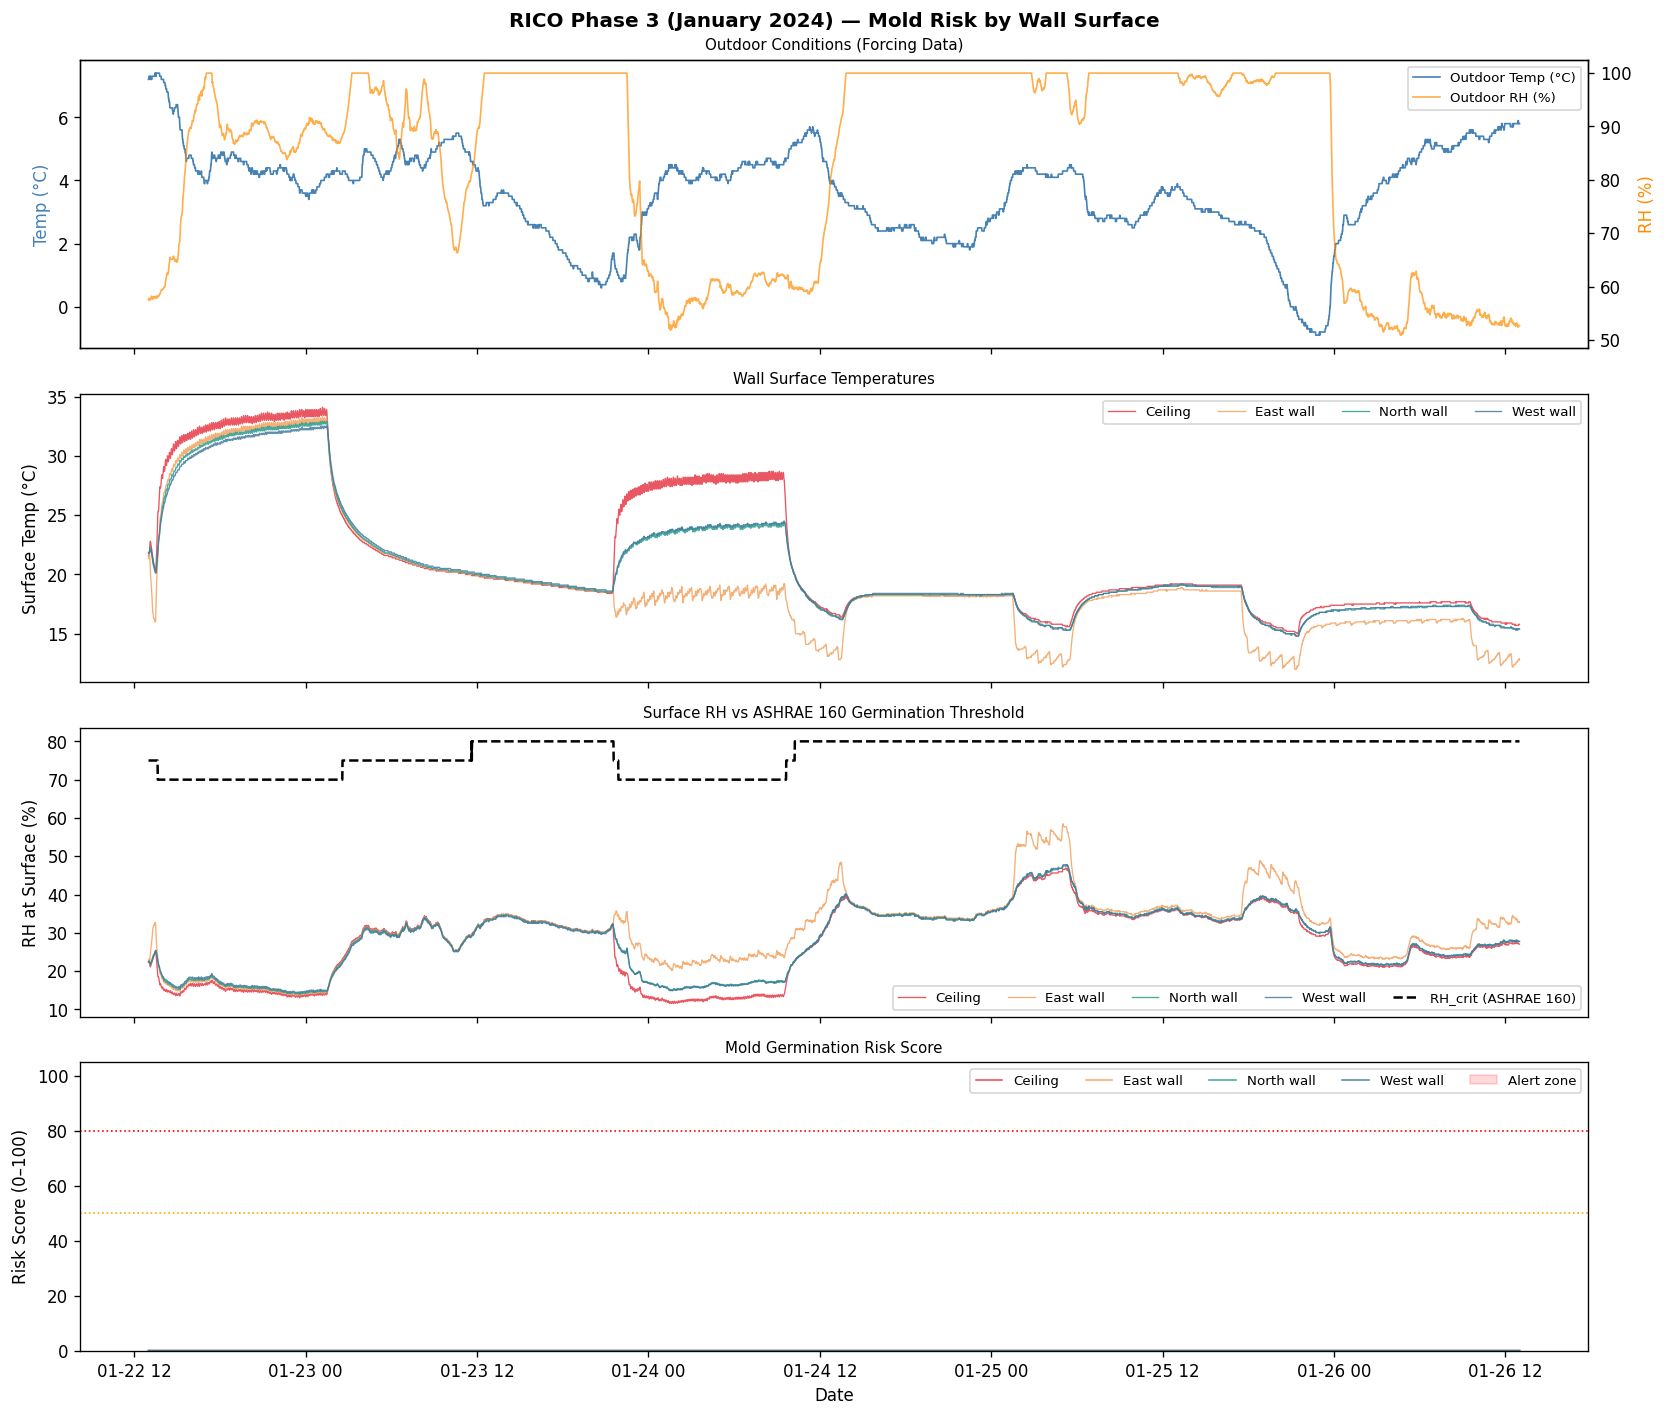

In [22]:
colors = ['#e63946', '#f4a261', '#2a9d8f', '#457b9d']
time_index = df.index

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
fig.suptitle("RICO Phase 3 (January 2024) — Mold Risk by Wall Surface",
             fontsize=12, fontweight='bold')

# Panel 1: outdoor conditions
ax = axes[0]
ax2 = ax.twinx()
ax.plot(time_index, df[OUTDOOR_TEMP_COL],
        color='steelblue', linewidth=1, label='Outdoor Temp (°C)')
ax2.plot(time_index, df[OUTDOOR_RH_COL],
         color='darkorange', linewidth=1, alpha=0.7,
         label='Outdoor RH (%)')
ax.set_ylabel("Temp (°C)", color='steelblue')
ax2.set_ylabel("RH (%)", color='darkorange')
ax.set_title("Outdoor Conditions (Forcing Data)", fontsize=9)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper right')

# Panel 2: wall surface temperatures
ax = axes[1]
for col, label, color in zip(SURFACE_TEMP_COLS, SURFACE_LABELS, colors):
    ax.plot(time_index, df[col], linewidth=0.8,
            label=label, color=color, alpha=0.85)
ax.set_ylabel("Surface Temp (°C)")
ax.set_title("Wall Surface Temperatures", fontsize=9)
ax.legend(fontsize=8, ncol=4)

# Panel 3: surface RH vs critical threshold
ax = axes[2]
for label, color in zip(SURFACE_LABELS, colors):
    res = results_rico[label]
    ax.plot(time_index, res['rh_surface'] * 100,
            linewidth=0.8, color=color, alpha=0.85, label=label)
ax.plot(time_index, results_rico['Ceiling']['rh_crit'] * 100,
        color='black', linewidth=1.5, linestyle='--',
        label='RH_crit (ASHRAE 160)')
ax.set_ylabel("RH at Surface (%)")
ax.set_title("Surface RH vs ASHRAE 160 Germination Threshold", fontsize=9)
ax.legend(fontsize=8, ncol=5)

# Panel 4: risk score
ax = axes[3]
for label, color in zip(SURFACE_LABELS, colors):
    res = results_rico[label]
    ax.plot(time_index, res['risk_score'],
            linewidth=1, color=color, alpha=0.85, label=label)
ax.axhline(50, color='orange', linestyle=':', linewidth=1)
ax.axhline(80, color='red', linestyle=':', linewidth=1)
ax.fill_between(time_index,
                results_rico['East wall']['risk_score'], 0,
                where=results_rico['East wall']['alert'],
                alpha=0.15, color='red', label='Alert zone')
ax.set_ylabel("Risk Score (0–100)")
ax.set_xlabel("Date")
ax.set_title("Mold Germination Risk Score", fontsize=9)
ax.set_ylim(0, 105)
ax.legend(fontsize=8, ncol=5)

plt.tight_layout()
plt.savefig(FIG_DIR / "02_rico_risk_trajectories.png",
            dpi=150, bbox_inches='tight')
plt.show()

In [23]:
seasonal_summary = []

for phase, df in rico.items():
    for col, label in zip(SURFACE_TEMP_COLS, SURFACE_LABELS):
        res = compute_moisture_index(
            df[col].values,
            df[OUTDOOR_TEMP_COL].values,
            df[OUTDOOR_RH_COL].values,
            dt_hours=1/60, material='drywall'
        )
        seasonal_summary.append({
            'phase':       phase,
            'season':      SEASON[phase],
            'surface':     label,
            'max_rh_surf': res['rh_surface'].max(),
            'mean_rh_surf':res['rh_surface'].mean(),
            'max_mi':      res['mi'].max(),
            'max_risk':    res['risk_score'].max(),
            'pct_alert':   res['alert'].mean() * 100,
        })

summary_df = pd.DataFrame(seasonal_summary)
print(summary_df.to_string(index=False))

 phase       season    surface  max_rh_surf  mean_rh_surf   max_mi  max_risk  pct_alert
     1 Summer (Jul)    Ceiling     0.682605      0.395228 0.000000  0.000000        0.0
     1 Summer (Jul)  East wall     0.687508      0.406419 0.000000  0.000000        0.0
     1 Summer (Jul) North wall     0.678580      0.393602 0.000000  0.000000        0.0
     1 Summer (Jul)  West wall     0.674582      0.393119 0.000000  0.000000        0.0
     2 Autumn (Oct)    Ceiling     0.680901      0.268544 0.000000  0.000000        0.0
     2 Autumn (Oct)  East wall     0.676432      0.280948 0.000000  0.000000        0.0
     2 Autumn (Oct) North wall     0.671995      0.268199 0.000000  0.000000        0.0
     2 Autumn (Oct)  West wall     0.658879      0.265510 0.000000  0.000000        0.0
     3 Winter (Jan)    Ceiling     0.468641      0.274030 0.000000  0.000000        0.0
     3 Winter (Jan)  East wall     0.584445      0.305527 0.000000  0.000000        0.0
     3 Winter (Jan) North wall  

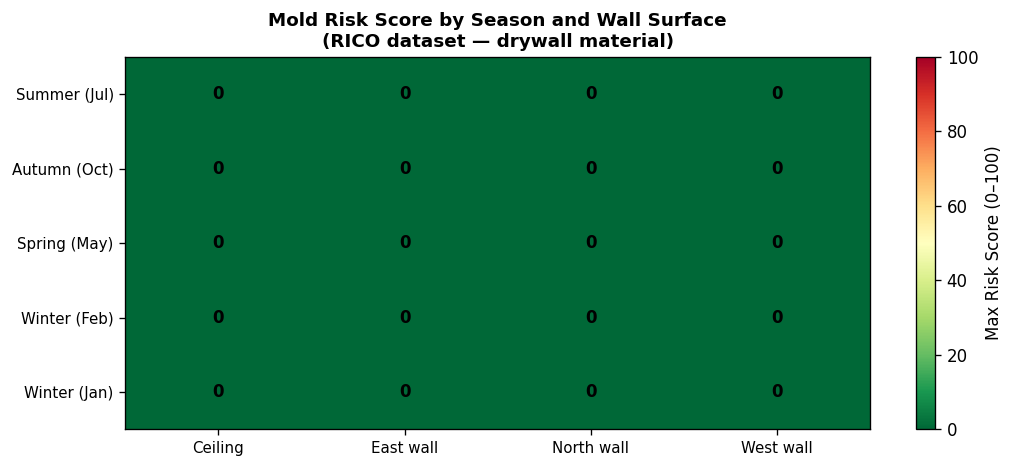

In [24]:
pivot = summary_df.pivot_table(
    index='season', columns='surface',
    values='max_risk', aggfunc='max'
)

# Sort by season order
season_order = ['Summer (Jul)', 'Autumn (Oct)',
                'Spring (May)', 'Winter (Feb)', 'Winter (Jan)']
pivot = pivot.reindex([s for s in season_order if s in pivot.index])

fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(pivot.values, cmap='RdYlGn_r',
               vmin=0, vmax=100, aspect='auto')
plt.colorbar(im, ax=ax, label='Max Risk Score (0–100)')

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, fontsize=9)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=9)
ax.set_title("Mold Risk Score by Season and Wall Surface\n"
             "(RICO dataset — drywall material)",
             fontsize=11, fontweight='bold')

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        ax.text(j, i, f"{val:.0f}",
                ha='center', va='center', fontsize=10,
                color='white' if val > 60 else 'black',
                fontweight='bold')

plt.tight_layout()
plt.savefig(FIG_DIR / "02_seasonal_risk_heatmap.png",
            dpi=150, bbox_inches='tight')
plt.show()

In [25]:
# Check what the actual temperature gradient looks like
df = rico[3]

print("January conditions — temperature gradient:")
print(f"  Outdoor air:        {df['WS1_Temperature'].mean():.1f}°C")
print(f"  Wall inner surface: {df[['BT.SIE_7','BT.SIN_17','BT.SIW_7']].mean().mean():.1f}°C")
print(f"  Room air:           {df[['BT.AOE','BT.AON','BT.AOW']].mean().mean():.1f}°C")
print(f"  Outdoor RH:         {df['WS1_Relative_humidity'].mean():.1f}%")

# The real mold risk zone is the wall cavity — between outer surface and inner surface
# Model cavity temp as interpolation: alpha=0 is outdoor, alpha=1 is indoor surface
print("\nSimulated cavity surface RH at different wall depths:")
print(f"{'Alpha (0=out, 1=in)':<25} {'Cavity Temp':>12} {'Surface RH':>12} {'RH_crit':>10} {'Exceeds?':>10}")
print("-" * 72)

t_out = df['WS1_Temperature'].mean()
t_in  = df[['BT.SIE_7','BT.SIN_17','BT.SIW_7']].mean().mean()
rh_out = df['WS1_Relative_humidity'].mean()

for alpha in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:
    t_cav = t_out + alpha * (t_in - t_out)
    rh_surf = surface_rh(t_cav, t_out, rh_out)
    rh_cr = rh_crit(t_cav)
    exceeds = "YES ⚠️" if rh_surf > rh_cr else "no"
    print(f"  alpha={alpha:.1f}              {t_cav:>12.1f}°C {rh_surf:>12.3f} {rh_cr:>10.3f} {exceeds:>10}")

January conditions — temperature gradient:
  Outdoor air:        3.6°C
  Wall inner surface: 20.2°C
  Room air:           22.6°C
  Outdoor RH:         84.5%

Simulated cavity surface RH at different wall depths:
Alpha (0=out, 1=in)        Cavity Temp   Surface RH    RH_crit   Exceeds?
------------------------------------------------------------------------
  alpha=0.0                       3.6°C        0.845      0.950         no
  alpha=0.1                       5.2°C        0.752      0.900         no
  alpha=0.2                       6.9°C        0.670      0.900         no
  alpha=0.3                       8.6°C        0.598      0.900         no
  alpha=0.4                      10.2°C        0.535      0.850         no
  alpha=0.5                      11.9°C        0.479      0.850         no
  alpha=0.6                      13.6°C        0.430      0.850         no
  alpha=0.7                      15.2°C        0.386      0.800         no
  alpha=0.8                      16.9°C  

In [26]:
import itertools

print("Conditions required to trigger mold risk (exceed RH_crit):")
print("="*65)
print(f"{'Out Temp':>10} {'Out RH':>8} {'Surface T':>10} {'Surf RH':>10} {'RH_crit':>9} {'Risk':>6}")
print("-"*65)

# Sweep outdoor RH and surface temperature combinations
for out_rh, out_t, surf_t in itertools.product(
    [70, 80, 90, 95, 100],   # outdoor RH %
    [5, 10, 15, 20],          # outdoor temp °C
    [10, 12, 15, 18, 20]      # wall surface temp °C
):
    rh_s  = float(surface_rh(surf_t, out_t, out_rh))
    rh_cr = float(rh_crit(surf_t))
    if rh_s > rh_cr:
        print(f"{out_t:>10}°C {out_rh:>7}% {surf_t:>9}°C "
              f"{rh_s:>10.3f} {rh_cr:>9.3f}  ⚠️ YES")
              

Conditions required to trigger mold risk (exceed RH_crit):
  Out Temp   Out RH  Surface T    Surf RH   RH_crit   Risk
-----------------------------------------------------------------
        15°C      70%        10°C      0.972     0.850  ⚠️ YES
        15°C      70%        12°C      0.851     0.850  ⚠️ YES
        20°C      70%        10°C      1.000     0.850  ⚠️ YES
        20°C      70%        12°C      1.000     0.850  ⚠️ YES
        20°C      70%        15°C      0.960     0.800  ⚠️ YES
        15°C      80%        10°C      1.000     0.850  ⚠️ YES
        15°C      80%        12°C      0.973     0.850  ⚠️ YES
        20°C      80%        10°C      1.000     0.850  ⚠️ YES
        20°C      80%        12°C      1.000     0.850  ⚠️ YES
        20°C      80%        15°C      1.000     0.800  ⚠️ YES
        20°C      80%        18°C      0.906     0.800  ⚠️ YES
        20°C      80%        20°C      0.800     0.750  ⚠️ YES
        10°C      90%        10°C      0.900     0.850  ⚠️ Y

In [27]:
# Load EPW weather files for the cavity simulations
EPW_DIR = BASE / "data/raw/epw"
epw_files = sorted(EPW_DIR.glob("*.epw"))

if not epw_files:
    print(f"No EPW files found in {EPW_DIR}")

def parse_epw(path):
    epw_cols = [
        "year","month","day","hour","minute",
        "data_source","dry_bulb_temp","dew_point_temp","rel_humidity",
        "atm_pressure","extraterr_horiz_rad","extraterr_direct_rad",
        "horiz_infrared_rad","global_horiz_rad","direct_normal_rad",
        "diffuse_horiz_rad","global_horiz_illum","direct_normal_illum",
        "diffuse_horiz_illum","zenith_luminance","wind_direction",
        "wind_speed","total_sky_cover","opaque_sky_cover","visibility",
        "ceiling_height","present_weather_obs","present_weather_codes",
        "precip_water","aerosol_opt_depth","snow_depth","days_since_snow",
        "albedo","liquid_precip_depth","liquid_precip_rate"
    ]
    df = pd.read_csv(path, skiprows=8, header=None,
                     names=epw_cols, usecols=range(len(epw_cols)))
    df["city"] = Path(path).stem
    return df[["city","month","day","hour",
               "dry_bulb_temp","dew_point_temp","rel_humidity","wind_speed"]]

epw_dfs = {f.stem[:20]: parse_epw(f) for f in epw_files}
print(f"Loaded EPW files: {len(epw_dfs)}")

Loaded EPW files: 4


In [28]:
# The EPW-driven simulation — this is ShieldNode's real use case
# Model: warm humid outdoor air, wall cavity surface cooled by AC interior

def simulate_wall_cavity(epw_df, indoor_ac_temp=22.0,
                         insulation_r=13, material='drywall'):
    """
    Simulate wall cavity conditions in an AC-cooled building
    in a hot humid climate.
    
    Physics:
    - Outdoor air is warm and humid (EPW data)
    - Indoor air is cooled by AC to ~22°C
    - Wall cavity surface temp = weighted blend of outdoor and indoor
      based on insulation R-value
    - Higher R = cavity closer to indoor temp (better insulated)
    - Lower R  = cavity closer to outdoor temp (poorly insulated)
    
    R-13 = standard US fiberglass batt (code minimum)
    R-6  = old/degraded insulation or no insulation
    """
    # Fraction of temperature gradient across insulation
    # R13 exterior = cavity sits ~80% toward indoor temp
    # R6  exterior = cavity sits ~60% toward indoor temp
    r_fractions = {6: 0.55, 13: 0.75, 19: 0.85, 30: 0.92}
    alpha = r_fractions.get(insulation_r, 0.75)
    
    out_temp = epw_df['dry_bulb_temp'].values.astype(float)
    out_rh   = epw_df['rel_humidity'].values.astype(float)
    
    # Cavity surface temperature
    cavity_temp = out_temp + alpha * (indoor_ac_temp - out_temp)
    
    return compute_moisture_index(
        surface_temp_c = cavity_temp,
        outdoor_temp_c = out_temp,
        outdoor_rh_pct = out_rh,
        dt_hours       = 1.0,   # EPW is hourly
        material       = material
    )

# Run for all 4 cities × 2 insulation levels
print(f"{'City':<25} {'R-value':>8} {'Max Risk%':>10} "
      f"{'Hours Alert':>12} {'% of Year':>10}")
print("-" * 68)

city_results = {}
for name, df in epw_dfs.items():
    for r_val in [6, 13]:
        res = simulate_wall_cavity(df, indoor_ac_temp=22.0,
                                   insulation_r=r_val)
        hours_alert = res['alert'].sum()
        pct_year    = hours_alert / 8760 * 100
        label = f"{name[:22]} R{r_val}"
        city_results[label] = res
        print(f"{name[:25]:<25} {r_val:>8} "
              f"{res['risk_score'].max():>10.1f}% "
              f"{hours_alert:>12} {pct_year:>10.1f}%")

City                       R-value  Max Risk%  Hours Alert  % of Year
--------------------------------------------------------------------
USA_CA_Port.Chicago.             6        0.1%            0        0.0%
USA_CA_Port.Chicago.            13        0.0%            0        0.0%
USA_FL_Miami.Intl.AP             6      100.0%         7317       83.5%
USA_FL_Miami.Intl.AP            13      100.0%         7402       84.5%
USA_LA_New.Orleans-N             6       79.3%         5338       60.9%
USA_LA_New.Orleans-N            13       91.1%         5330       60.8%
USA_TX_Houston-Bush.             6       83.5%         5969       68.1%
USA_TX_Houston-Bush.            13       94.3%         5949       67.9%


In [29]:
# Save the algorithm functions as a module
algo_code = '''
import numpy as np

def rh_crit(temp_c):
    temp_c = np.asarray(temp_c, dtype=float)
    return np.where(temp_c < 0, 1.0,
           np.where(temp_c < 5, 0.95,
           np.where(temp_c < 10, 0.90,
           np.where(temp_c < 15, 0.85,
           np.where(temp_c < 20, 0.80,
           np.where(temp_c < 25, 0.75, 0.70))))))

def e_sat(t):
    return 6.1078 * np.exp(17.27 * t / (t + 237.3))

def surface_rh(surface_temp_c, outdoor_temp_c, outdoor_rh_pct):
    e_out = (outdoor_rh_pct / 100.0) * e_sat(outdoor_temp_c)
    return np.clip(e_out / e_sat(surface_temp_c), 0.0, 1.0)

def compute_moisture_index(surface_temp_c, outdoor_temp_c,
                           outdoor_rh_pct, dt_hours=1/60,
                           material="drywall"):
    sensitivity = {"drywall": 1.0, "wood": 0.8, "concrete": 0.5}
    k = sensitivity.get(material, 1.0)
    surface_temp_c = np.asarray(surface_temp_c, dtype=float)
    outdoor_temp_c = np.asarray(outdoor_temp_c, dtype=float)
    outdoor_rh_pct = np.asarray(outdoor_rh_pct, dtype=float)
    n = len(surface_temp_c)
    rh_surf = surface_rh(surface_temp_c, outdoor_temp_c, outdoor_rh_pct)
    rh_cr   = rh_crit(surface_temp_c)
    excess  = rh_surf - rh_cr
    mi = np.zeros(n)
    for i in range(1, n):
        if excess[i] > 0:
            mi[i] = mi[i-1] + k * excess[i] * dt_hours
        else:
            mi[i] = max(0.0, mi[i-1] + k * 0.1 * excess[i] * dt_hours)
    return {
        "rh_surface": rh_surf, "rh_crit": rh_cr,
        "exceedance": excess,  "mi": mi,
        "risk_score": np.clip(mi / 720.0 * 100, 0, 100),
        "alert":      mi > 24.0,
    }
'''

algo_path = BASE / "notebooks" / "hygro_algo.py"
algo_path.write_text(algo_code)
print(f"Saved algorithm module → {algo_path}")

# Save seasonal summary
summary_df.to_parquet(PROC_DIR / "seasonal_risk_summary.parquet", index=False)
print(f"Saved seasonal_risk_summary.parquet  ({len(summary_df)} rows)")
print("\nNotebook 2 complete. Ready for Notebook 3.")

Saved algorithm module → /Users/arnavchavan/Desktop/mold_risk_model/notebooks/hygro_algo.py
Saved seasonal_risk_summary.parquet  (20 rows)

Notebook 2 complete. Ready for Notebook 3.
